In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration dyal les graphes (Alwan w l'kber)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Les bibliothèques sont prêtes !")

✅ Les bibliothèques sont prêtes !


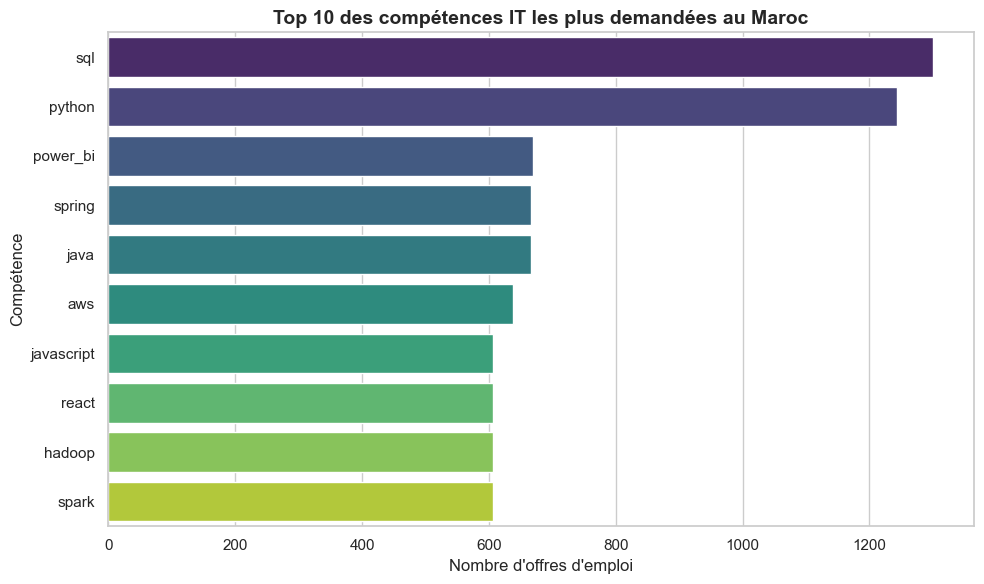

In [7]:
df_comp = pd.read_parquet('../data_lake/gold/top_competences.parquet')

top_global = df_comp.groupby('competence')['nb_offres_mentionnent'].sum().reset_index()
top_global = top_global.sort_values(by='nb_offres_mentionnent', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_global, x='nb_offres_mentionnent', y='competence', hue='competence', palette='viridis', legend=False)

plt.title('Top 10 des compétences IT les plus demandées au Maroc', fontsize=14, fontweight='bold')
plt.xlabel("Nombre d'offres d'emploi")
plt.ylabel('Compétence')
plt.tight_layout()

plt.show()

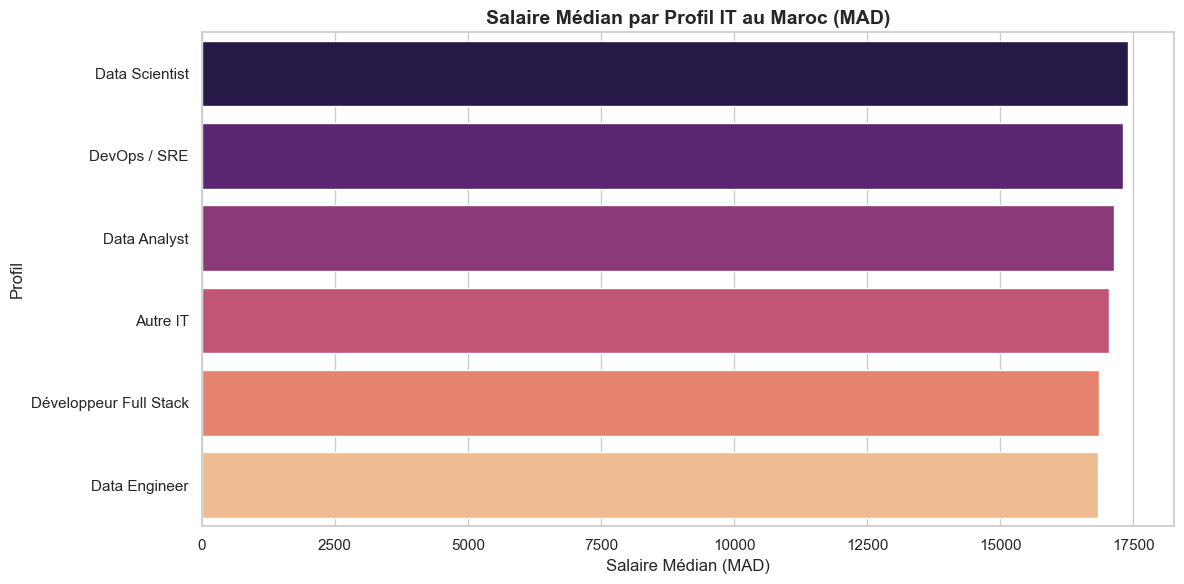

In [8]:
df_salaires = pd.read_parquet('../data_lake/gold/salaires_par_profil.parquet')

df_salaire_profil = df_salaires.groupby('profil')['salaire_median_mad'].mean().reset_index()
df_salaire_profil = df_salaire_profil.sort_values(by='salaire_median_mad', ascending=False)
df_salaires = pd.read_parquet('../data_lake/gold/salaires_par_profil.parquet')

df_salaire_profil = df_salaires.groupby('profil')['salaire_median_mad'].mean().reset_index()
df_salaire_profil = df_salaire_profil.sort_values(by='salaire_median_mad', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_salaire_profil, x='salaire_median_mad', y='profil', hue='profil', palette='magma', legend=False)

plt.title('Salaire Médian par Profil IT au Maroc (MAD)', fontsize=14, fontweight='bold')
plt.xlabel('Salaire Médian (MAD)')
plt.ylabel('Profil')
plt.tight_layout()

plt.show()

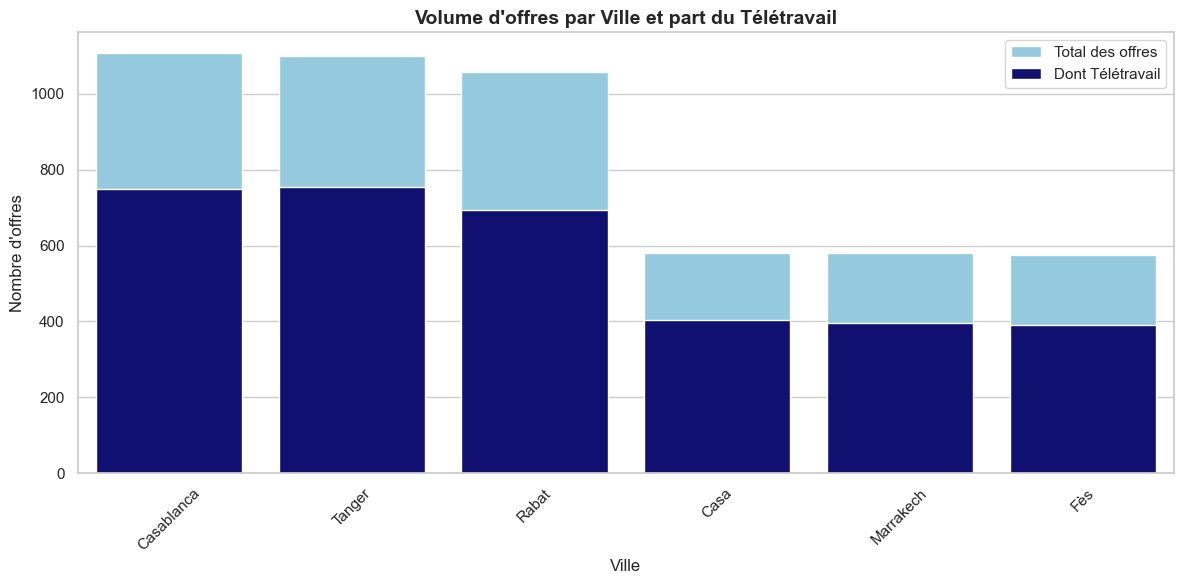

In [4]:
df_villes = pd.read_parquet('../data_lake/gold/offres_par_ville.parquet')

df_ville_grouped = df_villes.groupby('ville')[['nb_offres', 'nb_offres_remote']].sum().reset_index()
df_ville_grouped = df_ville_grouped.sort_values(by='nb_offres', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_ville_grouped, x='ville', y='nb_offres', color='skyblue', label='Total des offres')
sns.barplot(data=df_ville_grouped, x='ville', y='nb_offres_remote', color='navy', label='Dont Télétravail')

plt.title('Volume d\'offres par Ville et part du Télétravail', fontsize=14, fontweight='bold')
plt.xlabel('Ville')
plt.ylabel('Nombre d\'offres')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

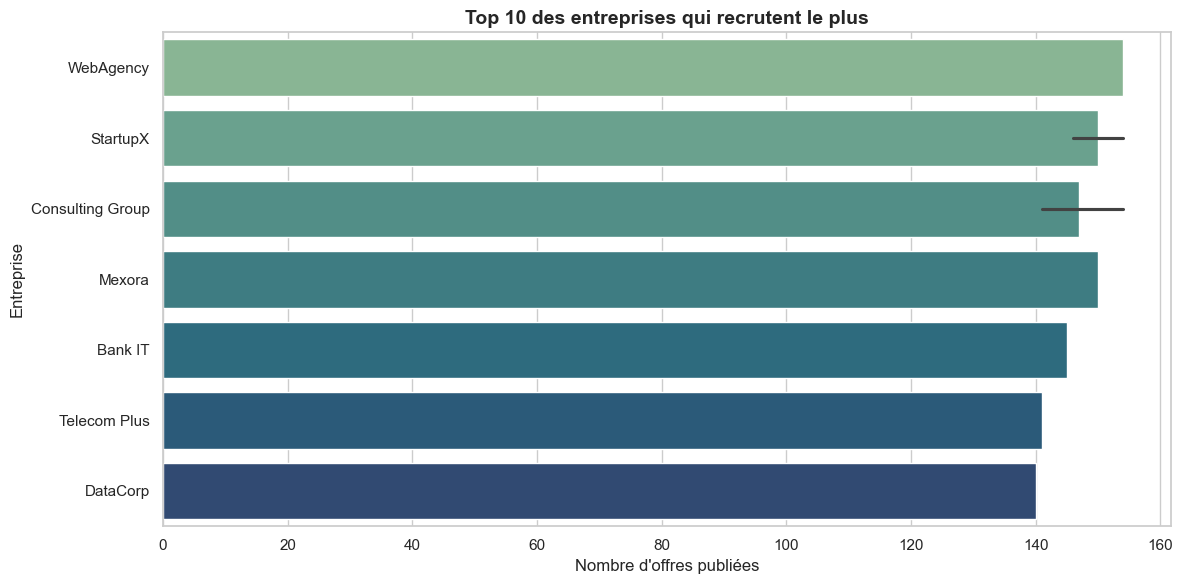

In [9]:
df_entreprises = pd.read_parquet('../data_lake/gold/entreprises_recruteurs.parquet')

top_entreprises = df_entreprises.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_entreprises, x='nb_offres_publiees', y='entreprise', hue='entreprise', palette='crest', legend=False)

plt.title('Top 10 des entreprises qui recrutent le plus', fontsize=14, fontweight='bold')
plt.xlabel('Nombre d\'offres publiées')
plt.ylabel('Entreprise')
plt.tight_layout()

plt.show()

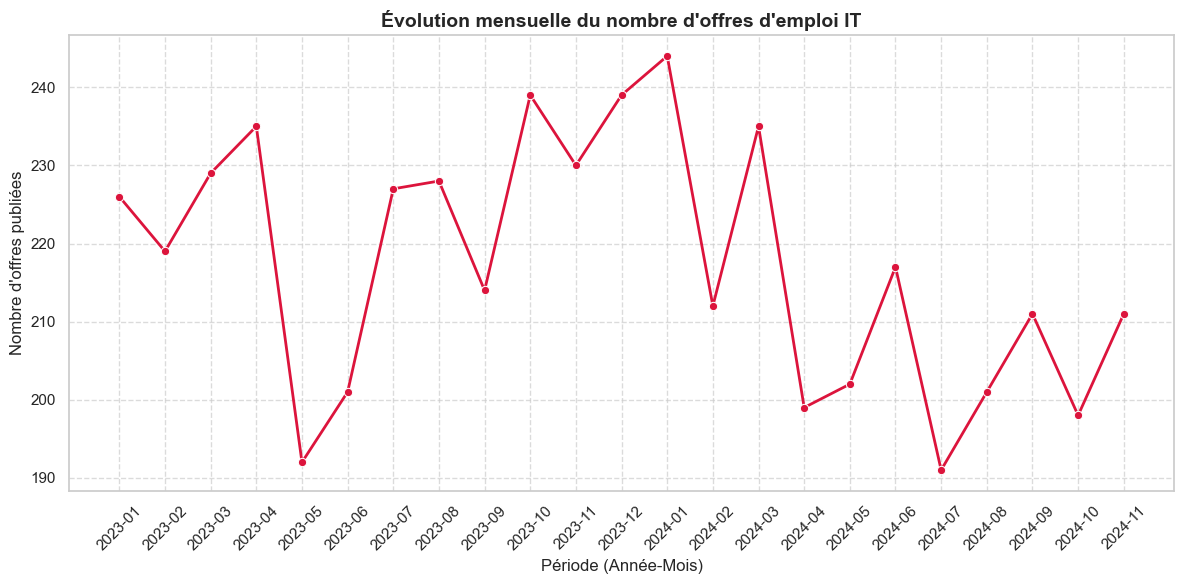

In [6]:
df_tendances = pd.read_parquet('../data_lake/gold/tendances_mensuelles.parquet')

df_tendances['date'] = df_tendances['annee'].astype(str) + '-' + df_tendances['mois'].astype(str).str.zfill(2)
tendance_globale = df_tendances.groupby('date')['nb_offres'].sum().reset_index()
tendance_globale = tendance_globale.sort_values(by='date')

plt.figure(figsize=(12, 6))
sns.lineplot(data=tendance_globale, x='date', y='nb_offres', marker='o', color='crimson', linewidth=2)

plt.title('Évolution mensuelle du nombre d\'offres d\'emploi IT', fontsize=14, fontweight='bold')
plt.xlabel('Période (Année-Mois)')
plt.ylabel('Nombre d\'offres publiées')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()